In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Online+Retail.xlsx to Online+Retail.xlsx


In [ ]:
print(uploaded.keys())

dict_keys(['Online+Retail.xlsx'])


In [ ]:
import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df = df.dropna(subset=['CustomerID'])

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
df.shape

(406829, 8)

In [ ]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(8905)

In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [ ]:
df.shape

(397924, 8)

In [ ]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(0)

In [ ]:
df['Quantity'].min()

1

In [ ]:
df['UnitPrice'].min()

0.0

In [ ]:
(df['UnitPrice'] == 0).sum()

np.int64(40)

In [ ]:
df = df[df['UnitPrice'] > 0]

In [ ]:
df['UnitPrice'].min()

0.001

In [ ]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [ ]:
df['TotalAmount'].mean()

np.float64(22.396999889415003)

In [ ]:
purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

purchase_frequency.head()

,InvoiceNo
CustomerID,
12346.0,1
12347.0,7
12348.0,4
12349.0,1
12350.0,1


In [ ]:
purchase_frequency.mean()

np.float64(4.272014753342554)

In [ ]:
customer_ltv = df.groupby('CustomerID')['TotalAmount'].sum()

In [ ]:
customer_ltv.mean()

np.float64(2054.2664601198708)

In [ ]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [ ]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [ ]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [ ]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [ ]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [ ]:
rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.35866818],
       [-0.90534032,  0.3544168 ,  0.25096626],
       [-0.17535959, -0.03533985, -0.02859601],
       [-0.73534481, -0.4250965 , -0.0330118 ],
       [ 2.17457836, -0.4250965 , -0.19134727]])

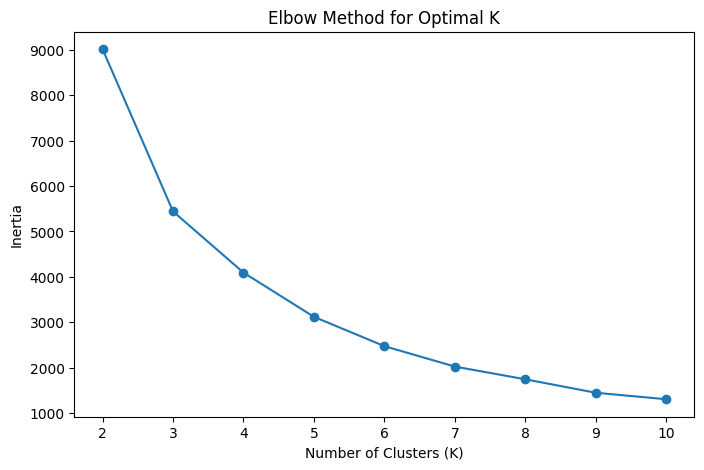

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [ ]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [ ]:
rfm['Cluster'].value_counts().sort_index()

,count
Cluster,
0,3054
1,1067
2,13
3,204


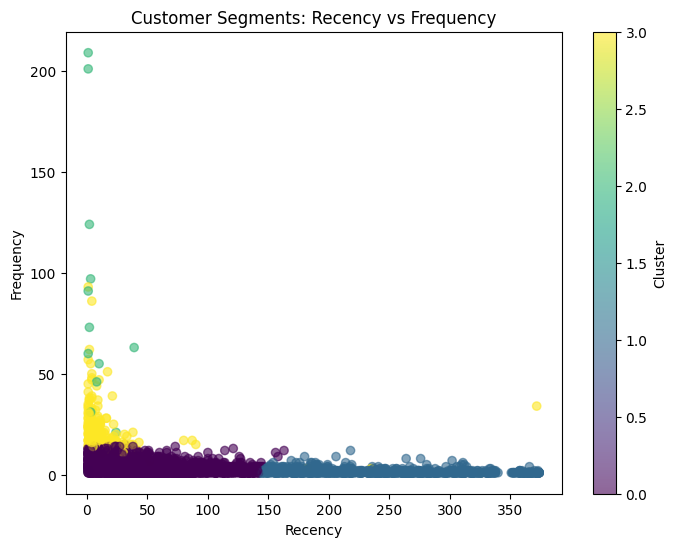

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    c=rfm['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.title('Customer Segments: Recency vs Frequency')
plt.colorbar(label='Cluster')
plt.show()

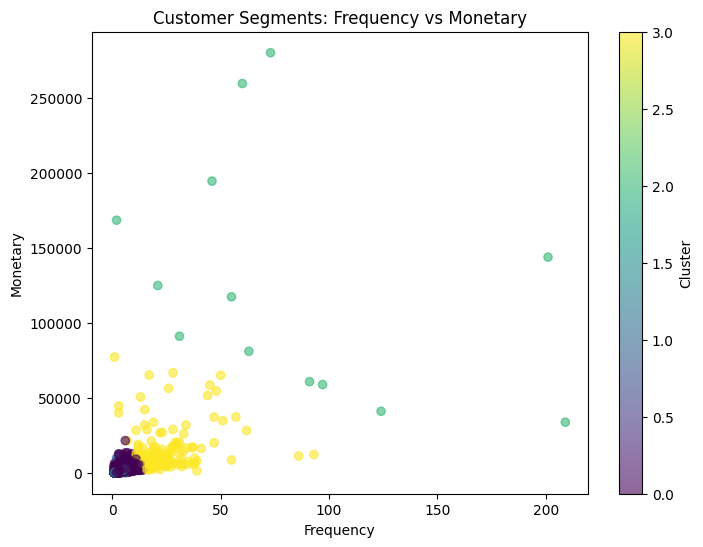

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segments: Frequency vs Monetary')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


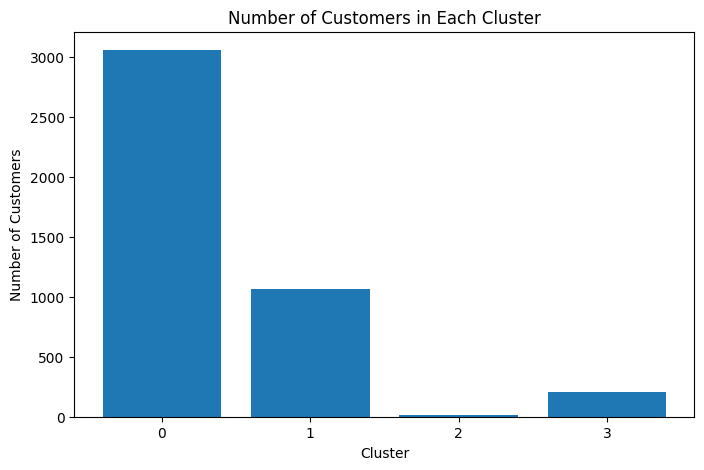

In [ ]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Cluster')

plt.show()

### Marketing Insights and Recommendations

* **Cluster 0 – Regular Customers:** These customers purchase regularly and have moderate spending. Loyalty rewards, cross-selling, and personalized offers can encourage them to purchase more frequently.

* **Cluster 1 – Inactive/Low-Value Customers:** These customers have not purchased recently and have relatively low spending. Win-back campaigns, limited-time discounts, and reactivation emails can be used to encourage them to return.

* **Cluster 2 – VIP Customers:** These customers have very high purchase frequency and spending and purchased recently. They can be targeted with VIP loyalty programs, exclusive offers, personalized recommendations, and priority services to maintain their engagement.

* **Cluster 3 – High-Value Frequent Customers:** These customers purchase frequently and generate high revenue. Loyalty rewards, premium products, upselling, and cross-selling can help retain and grow their value.

### Overall Insight

The RFM-based K-Means clustering divided customers into four groups with different purchasing behaviours. These segments can help businesses create targeted marketing strategies instead of using the same campaign for every customer.


## Conclusion

Customer segmentation was performed using RFM analysis and K-Means clustering. Customers were divided into four segments based on their recency, purchase frequency, and monetary value. The analysis identified regular customers, inactive/low-value customers, and high-value frequent customers, including a small group of VIP customers. These segments can help businesses understand customer purchasing behaviour and develop targeted marketing strategies for better customer retention and sales.
